# 04_Modelos

# 1. Carga de datos

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import sys

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)


import matplotlib as plt
import matplotlib.pyplot as plt
import joblib



root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

ROOT_DIR = Path(root_path)

import src.utils.utils as utils

%load_ext autoreload
%autoreload 2

DATA_PATH = ROOT_DIR /"notebooks" / "data" / "processed" / "telco_churn_feature_engineered.csv"
REPORTS_DIR = ROOT_DIR / "reports" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path("models")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)


df.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,is_new_customer,is_long_term_customer,avg_charge_per_tenure,monthly_to_tenure_ratio,services_count,is_month_to_month,is_one_year_contract,is_two_year_contract,has_auto_payment,has_fiber_optic
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,1,0,29.850000,14.925000,1,1,0,0,0,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,0,1,55.573529,1.627143,3,0,1,0,0,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,1,0,54.075000,17.950000,3,1,0,0,0,0
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,0,1,40.905556,0.919565,3,0,1,0,1,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,1,0,75.825000,23.566667,1,1,0,0,0,1


# 2. Separación Target y Varaibles

In [20]:
TARGET = "churn"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Distribución del target:")
print(y.value_counts(normalize=True).round(4))

Shape X: (7043, 31)
Shape y: (7043,)
Distribución del target:
churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


# 3. Train/Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Para datsets desbalanceados
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5634, 31)
Test: (1409, 31)


Identificamos las varaibles numéricas y categóricas

In [22]:
numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

Numéricas: ['senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_movies', 'paperless_billing', 'monthly_charges', 'total_charges', 'family_support', 'is_new_customer', 'is_long_term_customer', 'avg_charge_per_tenure', 'monthly_to_tenure_ratio', 'services_count', 'is_month_to_month', 'is_one_year_contract', 'is_two_year_contract', 'has_auto_payment', 'has_fiber_optic']
Categóricas: ['customer_i_d', 'gender', 'internet_service', 'streaming_t_v', 'contract', 'payment_method']


# 4. Preprocesado (aplicable en el pipeline)

In [23]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 5. Lista de modelos

In [24]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

Ahora, creamos una función para evaluar los modelos

In [25]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    
    return pipeline, results, y_pred, y_proba

# 6. Entrenamiento y evaluación

In [26]:
trained_models = {}
results_list = []

for name, model in models.items():
    pipeline, results, y_pred, y_proba = evaluate_model(model, X_train, y_train, X_test, y_test)
    trained_models[name] = pipeline
    results["model"] = name
    results_list.append(results)

results_df = pd.DataFrame(results_list).set_index("model")
results_df.sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
logistic_regression,0.761533,0.536260,0.751337,0.625835,0.847098
random_forest,0.792051,0.632787,0.516043,0.568483,0.833249


- Logistic Regresion:
    - Recall ($0.75$): Es lo mejor de este modelo. Es capaz de detectar al $75\%$ de los clientes que realmente se van a ir.
    - ROC AUC ($0.84$): Tiene una excelente capacidad para distinguir entre un cliente que se queda y uno que se va.
    - Precisión ($0.53$): Es su punto débil. De cada 100 alertas que lanza, casi la mitad son "falsas alarmas" (clientes que en realidad no pensaban irse).

- Random Forest:
    - Precisión ($0.63$): Es más fiable cuando dice que alguien se va a ir; falla menos en sus predicciones positivas que la regresión logística.
    - Accuracy ($0.79$): Es el modelo más exacto, en general, pero esto puede ser engañoso si los datos están desbalanceados.
    - Recall ($0.51$): Muy bajo. Se le escapan casi la mitad ($49\%$) de los clientes que realmente abandonan la compañía.

A la vista de estos resultados, es mejor la regresión logistica, ya que su capacidad de detección (Recall) es significativamente superior. El coste de perder un cliente que no detectamos (bajo Recall) suele ser mucho mayor que el coste de ofrecer un descuento o llamar por teléfono a un cliente que no pensaba irse (baja Precisión).

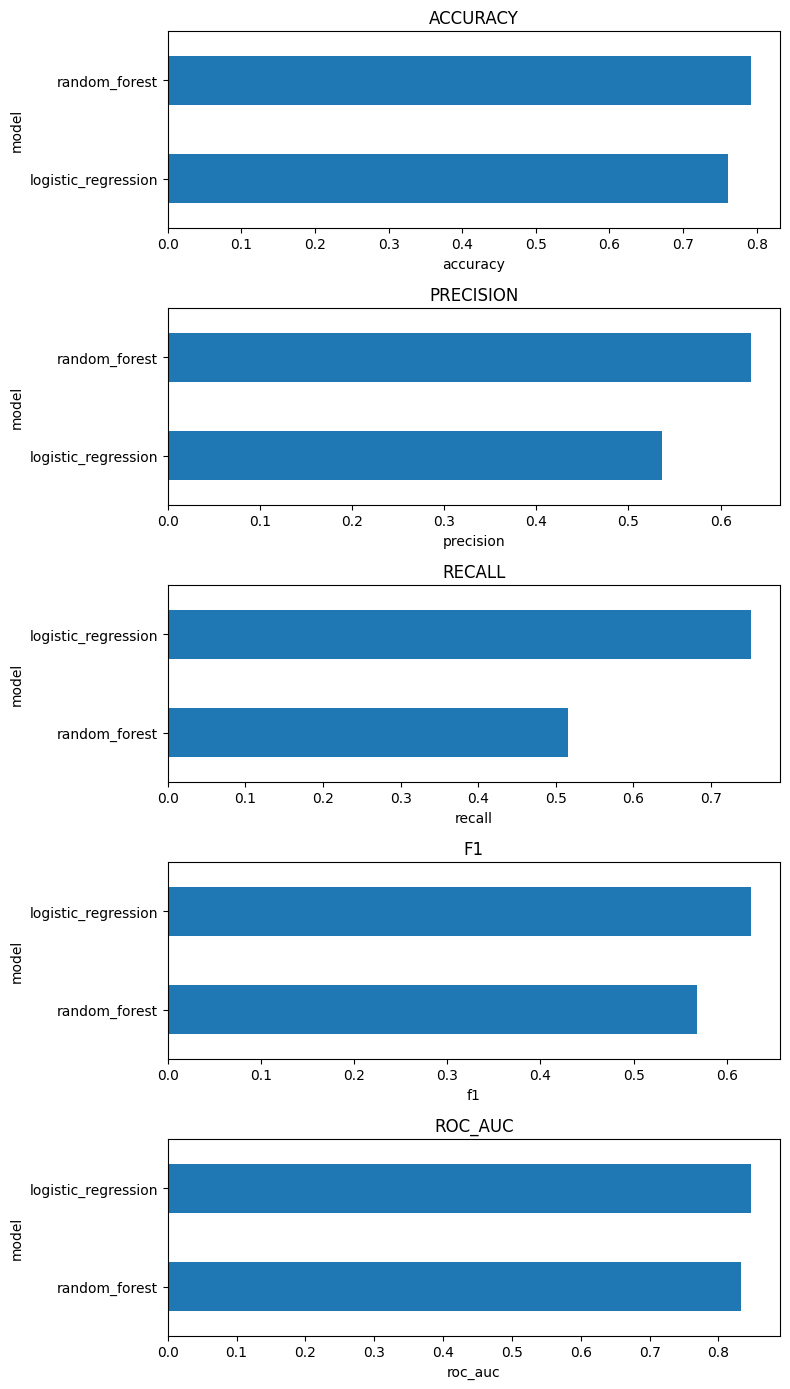

In [27]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(8, 14))

for ax, metric in zip(axes, metrics_to_plot):
    results_df[metric].sort_values().plot(kind="barh", ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel(metric)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison_metrics.png", dpi=150)
plt.show()

Confirmamos cuál es el mejor modelo:

In [28]:
best_model_name = results_df["roc_auc"].idxmax()
best_pipeline = trained_models[best_model_name]

print("Mejor modelo según ROC-AUC:", best_model_name)
print(results_df.loc[best_model_name])

Mejor modelo según ROC-AUC: logistic_regression
accuracy     0.761533
precision    0.536260
recall       0.751337
f1           0.625835
roc_auc      0.847098
Name: logistic_regression, dtype: float64


## 6.1. Matriz de confusión

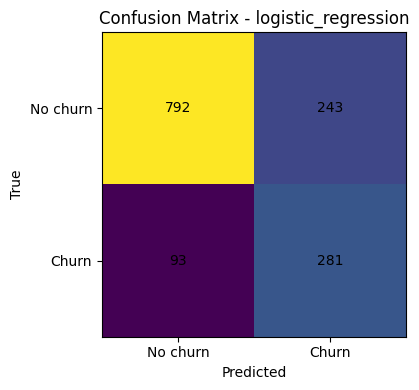

In [29]:
best_y_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title(f"Confusion Matrix - {best_model_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No churn", "Churn"])
ax.set_yticklabels(["No churn", "Churn"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix_best_model.png", dpi=150)
plt.show()

Como vemos, el modelo predijo correctamente que 792 clientes no abandonarían (verdadero negativo); y se equivocó 243 veces al predecir que dichos clientes sí se irían (falso positivo).

Por otro lado, se equivocó 93 veces al predecir que esos clientes no abandonarían, cuando la realidad fue la contraria (falso negativo); y predijo correctamente que 281 clientes sí abandonarían (verdadero positivo)  

## 6.2. Validación cruzada

Ahora hacemos una validación más consistente del modelo para confirmar que no acierta por simple suerte:

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    metric: [cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std()]
    for metric in scoring
}, index=["mean", "std"])

cv_summary.T

,mean,std
accuracy,0.769971,0.014320
precision,0.549302,0.020555
recall,0.742475,0.030433
f1,0.631357,0.023365
roc_auc,0.848623,0.011636


# 7. Guardamos el modelo

In [31]:
joblib.dump(best_pipeline, MODEL_DIR / f"{best_model_name}.pkl")
print("Modelo guardado en:", MODEL_DIR / f"{best_model_name}.pkl")

Modelo guardado en: models\logistic_regression.pkl
